In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

filepath = '/mnt/diffuse-shared/xray/steve/mdx-examples/lys_tri_model/export/lys_tri_goodvibes.h5'

with h5py.File(filepath, 'r') as f:
    I_data = f['maps/supercell/I'][()]   # full path as a string, works because it's a Dataset
    print(I_data.shape, I_data.dtype)

(319, 583, 585) float32


In [2]:
np.isnan(I_data).all()

np.False_

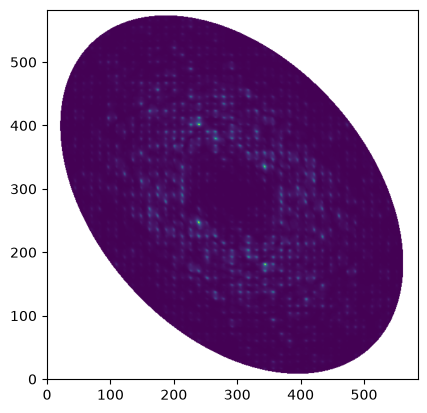

In [3]:
plt.imshow(I_data[7],origin='lower')

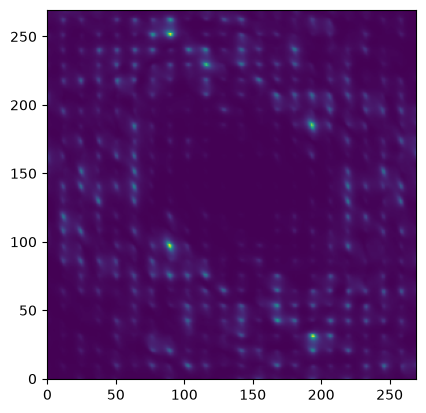

In [4]:
plt.imshow(I_data[7][150:420,150:420],origin='lower')

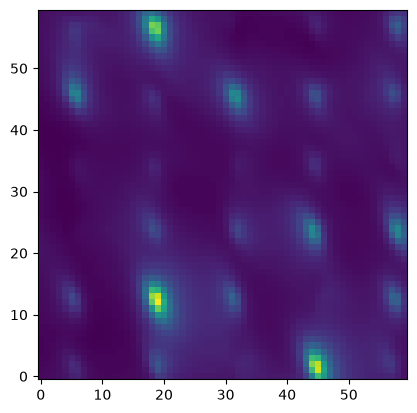

In [5]:
plt.imshow(I_data[7][300:360,130:190],origin='lower')

In [6]:
# #may have to pip install
# import imageio.v2 as imageio
# import io

# frames = []

# with h5py.File(filepath, 'r') as f:
#     I_data = f['maps/supercell/I']  # dataset object, not loaded into memory yet

#     # figure out a consistent color scale across all frames (optional but recommended)
#     vmin, vmax = None, None
#     # Uncomment to compute global min/max across the slice range for consistent scaling:
#     # sample = I_data[6:295, 300:360, 130:190]
#     # vmin, vmax = np.nanmin(sample), np.nanmax(sample)

#     for k in range(6, 295):  # 6 to 294 inclusive
#         fig, ax = plt.subplots(figsize=(5, 5))
#         im = ax.imshow(I_data[k][300:360, 130:190], origin='lower', vmin=vmin, vmax=vmax)
#         ax.set_title(f'h = {k}')
#         ax.axis('off')

#         # render figure to an in-memory buffer, then to an array
#         buf = io.BytesIO()
#         fig.savefig(buf, format='png', dpi=100, bbox_inches='tight')
#         plt.close(fig)
#         buf.seek(0)
#         frames.append(imageio.imread(buf))

# # write out the gif
# imageio.mimsave('lys_tri_goodvibes.gif', frames, fps=10)
# print("Saved GIF with", len(frames), "frames")

In [7]:
import hdf5storage
data = hdf5storage.loadmat('/mnt/diffuse-shared/xray/steve/mdx-examples/lys_tri_model/proc/goodvibes_fit.mat')

Text(0.5, 0, 'Spring index')

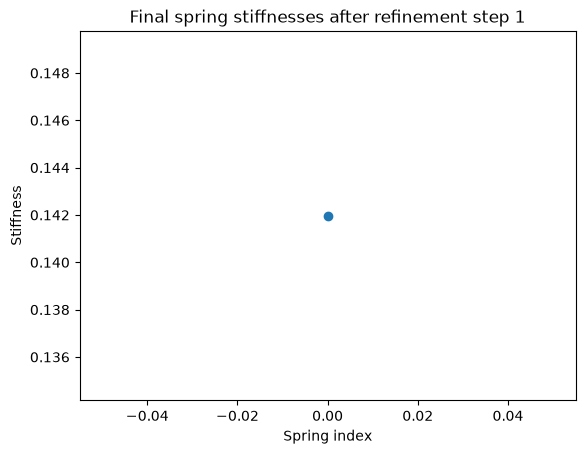

In [8]:
plt.scatter(np.arange(len(data['refineLog'][0][0][3].T[0])),data['refineLog'][0][0][3].T[0])
plt.title('Final spring stiffnesses after refinement step 1')
plt.ylabel('Stiffness')
plt.xlabel('Spring index')

Text(0.5, 0, 'Spring index')

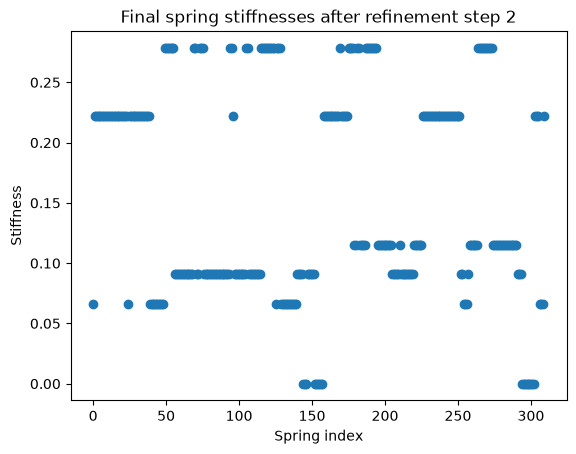

In [9]:
plt.scatter(np.arange(len(data['refineLog'][0][1][3].T[0])),data['refineLog'][0][1][3].T[0])
plt.title('Final spring stiffnesses after refinement step 2')
plt.ylabel('Stiffness')
plt.xlabel('Spring index')

In [10]:
#exactly twice as many as I have, since all springs are inter-cell! Probably the Gaussian parameter for each spring, 6 interfaces.
len(data['refineLog'][0][1][3].T[0])

310

Text(0.5, 0, 'Spring index')

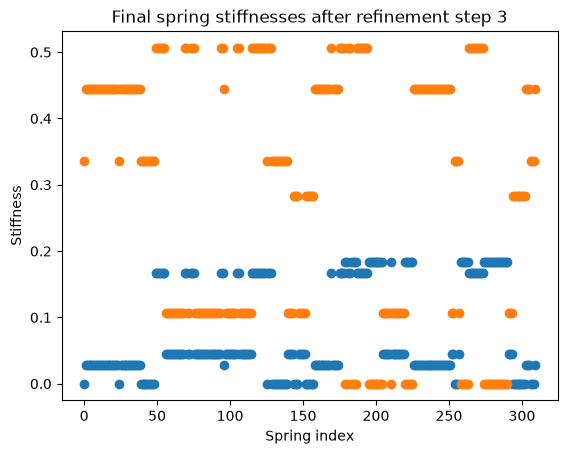

In [11]:
#probably the hybrid parameters for each spring, 6 interfaces.
plt.scatter(np.arange(len(data['refineLog'][0][2][3].T[0])),data['refineLog'][0][2][3].T[0])
plt.scatter(np.arange(len(data['refineLog'][0][2][3].T[1])),data['refineLog'][0][2][3].T[1])
plt.title('Final spring stiffnesses after refinement step 3')
plt.ylabel('Stiffness')
plt.xlabel('Spring index')

Text(0.5, 0, 'Spring index')

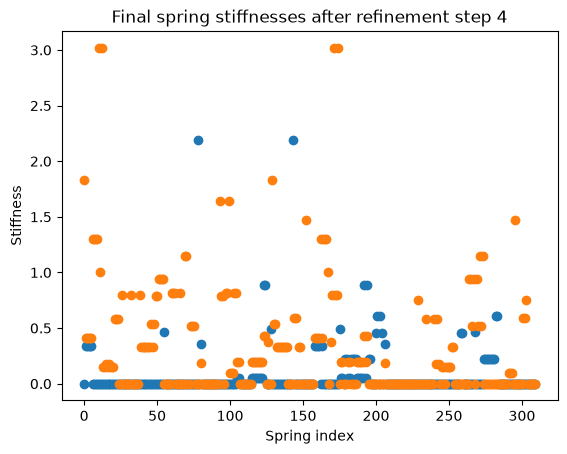

In [12]:
#probably the hybrid parameters for each spring, many different values at each interfaces.
plt.scatter(np.arange(len(data['refineLog'][0][3][3].T[0])),data['refineLog'][0][3][3].T[0])
plt.scatter(np.arange(len(data['refineLog'][0][3][3].T[1])),data['refineLog'][0][3][3].T[1])
plt.title('Final spring stiffnesses after refinement step 4')
plt.ylabel('Stiffness')
plt.xlabel('Spring index')

Text(0, 0.5, 'Stiffness')

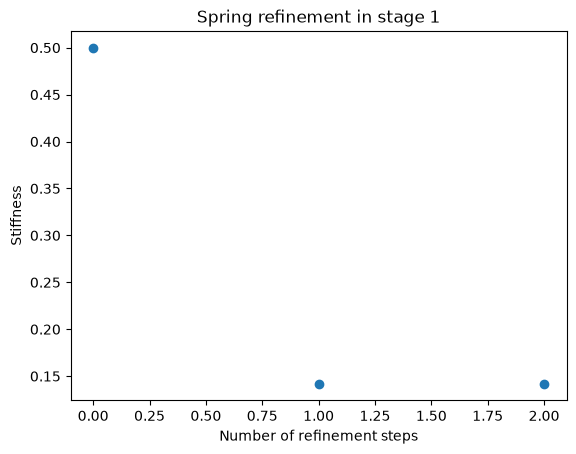

In [13]:
colors = plt.cm.tab20(np.linspace(0, 1, 20))
iters = []
for k in range(3):
    iters.append(data['refineLog'][0][0][1][k][0][1][0][0])
plt.scatter(np.arange(len(iters)),iters, color=colors[0])
plt.title('Spring refinement in stage 1')
plt.xlabel('Number of refinement steps')
plt.ylabel('Stiffness')

Text(0, 0.5, 'Stiffness')

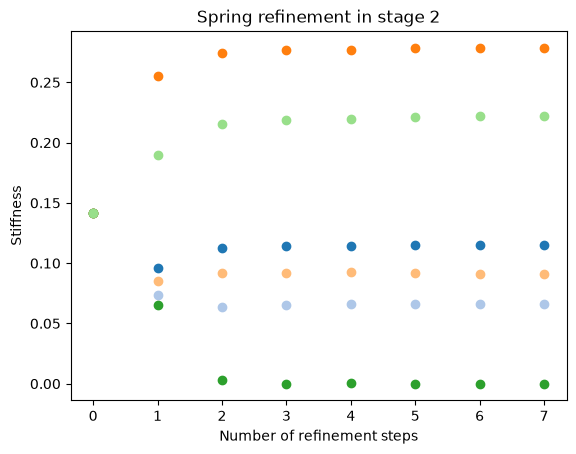

In [14]:
iters = []
for k in range(8):
    iters.append(data['refineLog'][0][1][1][k][0][1])
iters=np.array(iters)
for k in range(len(iters.T[0])):
    color = colors[k % len(colors)]
    plt.scatter(np.arange(len(iters.T[0][k])),iters.T[0][k], color=color)
plt.title('Spring refinement in stage 2')
plt.xlabel('Number of refinement steps')
plt.ylabel('Stiffness')

Text(0, 0.5, 'Stiffness')

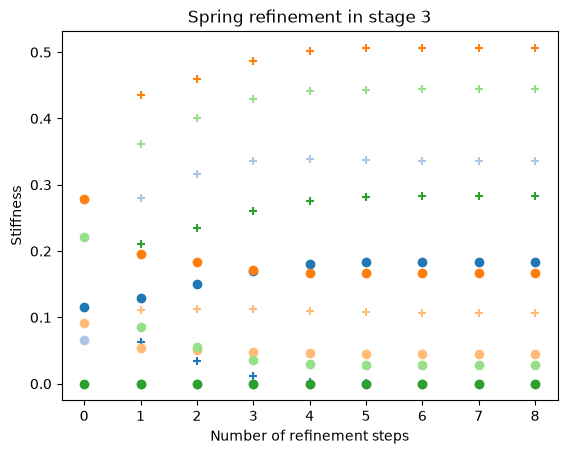

In [15]:
k1s = []
k2s = []
for k in range(9):
    k1s.append(data['refineLog'][0][2][1][k][0][1].T[0])
    k2s.append(data['refineLog'][0][2][1][k][0][1].T[1])
k1s=np.array(k1s)
k2s=np.array(k2s)
for k in range(len(k1s.T)):
    color = colors[k % len(colors)]
    plt.scatter(np.arange(len(k1s.T[k])),k1s.T[k], color=color)
    plt.scatter(np.arange(len(k2s.T[k])),k2s.T[k], color=color,marker='+')
    
plt.title('Spring refinement in stage 3')
plt.xlabel('Number of refinement steps')
plt.ylabel('Stiffness')

Text(0, 0.5, 'Stiffness')

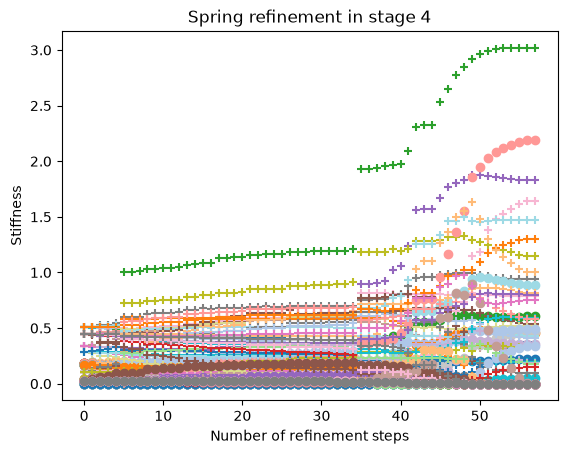

In [16]:
k1s = []
k2s = []
for k in range(58):
    k1s.append(data['refineLog'][0][3][1][k][0][1].T[0])
    k2s.append(data['refineLog'][0][3][1][k][0][1].T[1])
k1s=np.array(k1s)
k2s=np.array(k2s)
for k in range(len(k1s.T)):
    color = colors[k % len(colors)]
    plt.scatter(np.arange(len(k1s.T[k])),k1s.T[k], color=color)
    plt.scatter(np.arange(len(k2s.T[k])),k2s.T[k], color=color,marker='+')
    
plt.title('Spring refinement in stage 4')
plt.xlabel('Number of refinement steps')
plt.ylabel('Stiffness')

Text(0, 0.5, 'Stiffness')

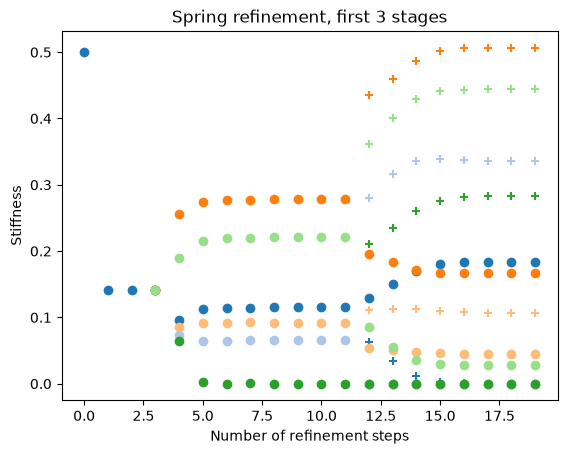

In [17]:
#Stage 1
iters = []
for k in range(3):
    iters.append(data['refineLog'][0][0][1][k][0][1][0][0])
plt.scatter(np.arange(len(iters)),iters, color=colors[0])

#Stage 2
iters = []
for k in range(8):
    iters.append(data['refineLog'][0][1][1][k][0][1])
iters=np.array(iters)
for k in range(len(iters.T[0])):
    color = colors[k % len(colors)]
    plt.scatter(np.arange(len(iters.T[0][k]))+3,iters.T[0][k], color=color)
plt.title('Spring refinement in stage 2')
plt.xlabel('Number of refinement steps')
plt.ylabel('Stiffness')

#Stage 3
k1s = []
k2s = []
for k in range(9):
    k1s.append(data['refineLog'][0][2][1][k][0][1].T[0])
    k2s.append(data['refineLog'][0][2][1][k][0][1].T[1])
k1s=np.array(k1s)
k2s=np.array(k2s)
for k in range(len(k1s.T)):
    color = colors[k % len(colors)]
    plt.scatter(np.arange(len(k1s.T[k]))+11,k1s.T[k], color=color)
    plt.scatter(np.arange(len(k2s.T[k]))+11,k2s.T[k], color=color,marker='+')

plt.title('Spring refinement, first 3 stages')
plt.xlabel('Number of refinement steps')
plt.ylabel('Stiffness')

Text(0, 0.5, 'Stiffness')

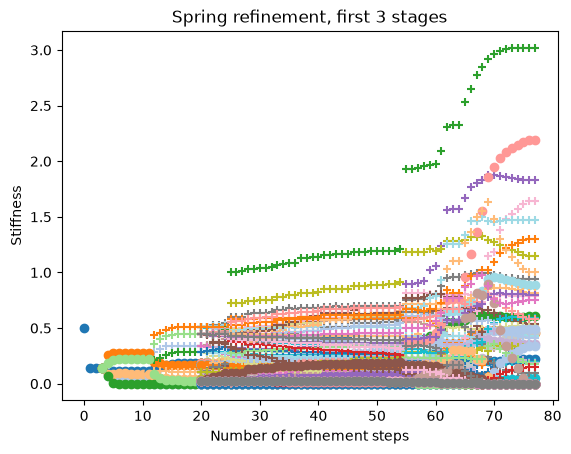

In [18]:
#Stage 1
iters = []
for k in range(3):
    iters.append(data['refineLog'][0][0][1][k][0][1][0][0])
plt.scatter(np.arange(len(iters)),iters, color=colors[0])

#Stage 2
iters = []
for k in range(8):
    iters.append(data['refineLog'][0][1][1][k][0][1])
iters=np.array(iters)
for k in range(len(iters.T[0])):
    color = colors[k % len(colors)]
    plt.scatter(np.arange(len(iters.T[0][k]))+3,iters.T[0][k], color=color)
plt.title('Spring refinement in stage 2')
plt.xlabel('Number of refinement steps')
plt.ylabel('Stiffness')

#Stage 3
k1s = []
k2s = []
for k in range(9):
    k1s.append(data['refineLog'][0][2][1][k][0][1].T[0])
    k2s.append(data['refineLog'][0][2][1][k][0][1].T[1])
k1s=np.array(k1s)
k2s=np.array(k2s)
for k in range(len(k1s.T)):
    color = colors[k % len(colors)]
    plt.scatter(np.arange(len(k1s.T[k]))+11,k1s.T[k], color=color)
    plt.scatter(np.arange(len(k2s.T[k]))+11,k2s.T[k], color=color,marker='+')

#Stage 4
k1s = []
k2s = []
for k in range(58):
    k1s.append(data['refineLog'][0][3][1][k][0][1].T[0])
    k2s.append(data['refineLog'][0][3][1][k][0][1].T[1])
k1s=np.array(k1s)
k2s=np.array(k2s)
for k in range(len(k1s.T)):
    color = colors[k % len(colors)]
    plt.scatter(np.arange(len(k1s.T[k]))+20,k1s.T[k], color=color)
    plt.scatter(np.arange(len(k2s.T[k]))+20,k2s.T[k], color=color,marker='+')

plt.title('Spring refinement, first 3 stages')
plt.xlabel('Number of refinement steps')
plt.ylabel('Stiffness')